In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from _setup import evaluate_models, make_spark
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression, RandomForestClassifier
from pyspark.ml.clustering import GaussianMixture, KMeans
from pyspark.ml.evaluation import ClusteringEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import StandardScaler, StringIndexer, VectorAssembler
from sklearn.datasets import load_iris
from sklearn.metrics import adjusted_rand_score

SEED = 42
spark = make_spark("hw3-iris")
spark

In [2]:
iris = load_iris(as_frame=True)
pdf = iris.frame.rename(
    columns={
        "sepal length (cm)": "sepal_length",
        "sepal width (cm)": "sepal_width",
        "petal length (cm)": "petal_length",
        "petal width (cm)": "petal_width",
        "target": "label_idx",
    }
)
target_names = [str(n) for n in iris.target_names]
pdf["species"] = pdf["label_idx"].map(dict(enumerate(target_names)))
pdf = pdf.drop(columns=["label_idx"])

df = spark.createDataFrame(pdf)
df.show(5)
df.printSchema()

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows

root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- species: string (nullable = true)



In [3]:
df.describe().toPandas()

,summary,sepal_length,sepal_width,petal_length,petal_width,species
0,count,150,150,150,150,150
1,mean,5.843333333333334,3.057333333333333,3.7580000000000005,1.1993333333333334,None
2,stddev,0.8280661279778628,0.4358662849366982,1.7652982332594662,0.7622376689603465,None
3,min,4.3,2.0,1.0,0.1,setosa
4,max,7.9,4.4,6.9,2.5,virginica


In [4]:
df.groupBy("species").count().show()

+----------+-----+
|   species|count|
+----------+-----+
|    setosa|   50|
|versicolor|   50|
| virginica|   50|
+----------+-----+



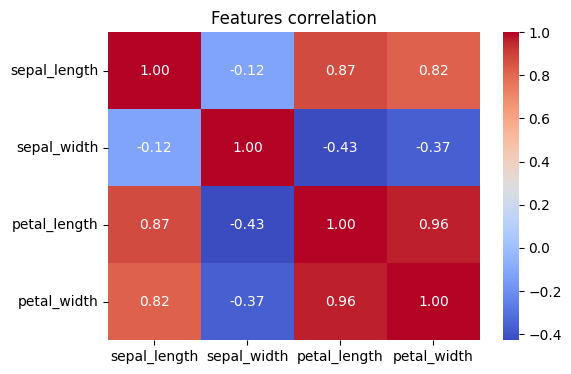

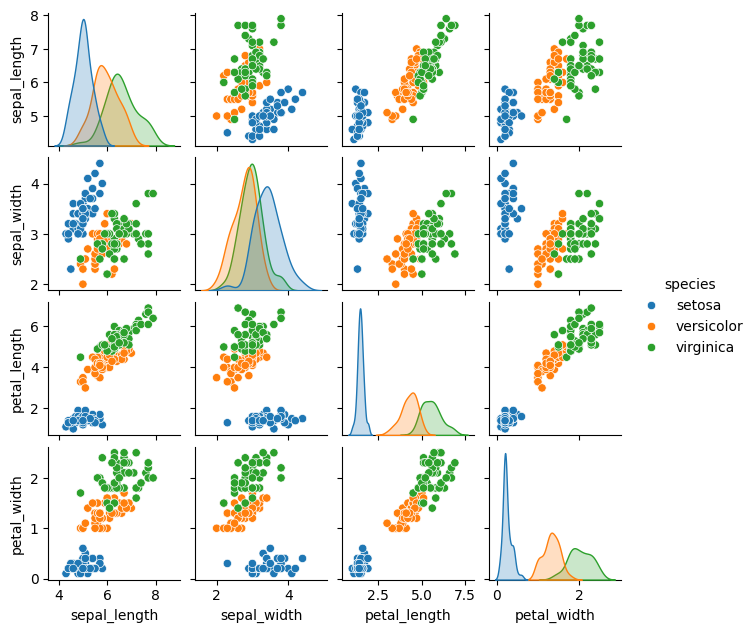

In [5]:
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pdf[feature_cols].corr(), annot=True, cmap="coolwarm", ax=ax, fmt=".2f")
ax.set_title("Features correlation")
plt.show()

sns.pairplot(pdf, hue="species", vars=feature_cols, height=1.6)
plt.show()

In [6]:
prep = Pipeline(
    stages=[
        VectorAssembler(inputCols=feature_cols, outputCol="features_raw"),
        StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True),
        StringIndexer(inputCol="species", outputCol="label"),
    ]
).fit(df)
data = prep.transform(df).select("features", "label", "species")

train, test = data.randomSplit([0.7, 0.3], seed=SEED)
print(f"train: {train.count()}, test: {test.count()}")

train: 105, test: 45


In [7]:
classifiers = {
    "LogisticRegression": LogisticRegression(featuresCol="features", labelCol="label", maxIter=50),
    "RandomForest": RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, seed=SEED),
    "DecisionTree": DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=SEED),
}
evaluators = {
    "accuracy": MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy"),
    "f1": MulticlassClassificationEvaluator(labelCol="label", metricName="f1"),
}
evaluate_models(classifiers, train, test, evaluators)

,accuracy,f1
model,,
LogisticRegression,0.933333,0.934392
RandomForest,0.933333,0.934392
DecisionTree,0.933333,0.934392


In [8]:
sil_eval = ClusteringEvaluator(featuresCol="features", predictionCol="prediction", metricName="silhouette")
clusterers = {
    "KMeans": KMeans(k=3, featuresCol="features", seed=SEED),
    "GaussianMixture": GaussianMixture(k=3, featuresCol="features", seed=SEED),
}

rows = []
for name, clu in clusterers.items():
    pred = clu.fit(data).transform(data)
    pdf_pred = pred.select("label", "prediction").toPandas()
    rows.append(
        {
            "model": name,
            "silhouette": sil_eval.evaluate(pred),
            "ARI": adjusted_rand_score(pdf_pred["label"], pdf_pred["prediction"]),
        }
    )
pd.DataFrame(rows).set_index("model")

,silhouette,ARI
model,,
KMeans,0.654497,0.592333
GaussianMixture,0.383046,0.574404


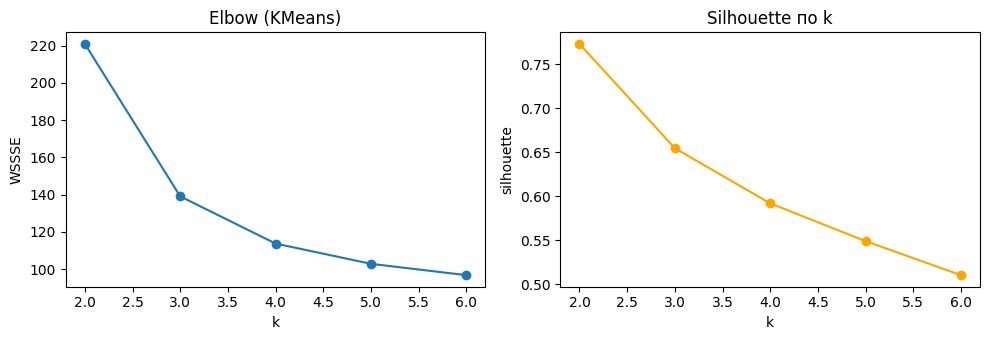

In [9]:
ks = list(range(2, 7))
wssse = []
sil = []
for k in ks:
    m = KMeans(k=k, featuresCol="features", seed=SEED).fit(data)
    p = m.transform(data)
    wssse.append(m.summary.trainingCost)
    sil.append(sil_eval.evaluate(p))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(ks, wssse, marker="o")
axes[0].set(xlabel="k", ylabel="WSSSE", title="Elbow (KMeans)")
axes[1].plot(ks, sil, marker="o", color="orange")
axes[1].set(xlabel="k", ylabel="silhouette", title="Silhouette по k")
plt.tight_layout()
plt.show()

## Выводы

- Классификация: все три модели — accuracy ≥ 0.9 на тесте, ошибки на границе versicolor↔virginica.
- Кластеризация: KMeans и GaussianMixture с `k=3` находят структуру, близкую к истинным классам (ARI ≈ 0.6–0.7); setosa выделяется идеально, versicolor/virginica путаются.
- Elbow + silhouette подтверждают `k=3` как разумный выбор.

In [10]:
spark.stop()